# OS3 — XGBoost 回归复现版（可直接运行）
本 Notebook 旨在帮助你在新环境中**稳定复现**：数据读取 → 特征工程（OneHotEncoder）→ 模型训练（XGBRegressor）→ 交叉验证 → 评估 → 导出预测/特征重要性。

> 生成时间：2025-11-10 08:02:18


## 0. 环境与版本检查


In [1]:
# 如果缺库，先在终端或此处安装，例如：
# !pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn

import sys, platform
import numpy as np, pandas as pd
import sklearn
import xgboost
import seaborn as sns
import matplotlib
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('xgboost:', xgboost.__version__)
print('seaborn:', sns.__version__)
print('matplotlib:', matplotlib.__version__)


Python: 3.13.5
Platform: Windows-11-10.0.22631-SP0
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.7.1
xgboost: 3.0.4
seaborn: 0.13.2
matplotlib: 3.10.0


## 1. 可复现性设置（随机种子）


In [2]:
import os, random, numpy as np

SEED = 130  # 你可以改这个种子，但保持固定便于复现实验
random.seed(SEED)
np.random.seed(SEED)

# XGBoost 里也会传 random_state=SEED
print('Fixed SEED =', SEED)


Fixed SEED = 130


## 2. 数据路径设置
将你的数据文件路径填入 `DATA_PATH`。支持 `.xlsx` 或 `.csv`。


In [3]:
\
from pathlib import Path

# === 在这里替换为你的数据文件路径 ===
# 示例：DATA_PATH = r"D:\文件\贾粟-毕业论文\论文代码与建模\os3-3.27.xlsx"
DATA_PATH = r"D:\文件\贾琛-毕业论文\论文\数据\os3-3.27.xlsx"

if not DATA_PATH:
    raise ValueError("请在上方填写 DATA_PATH（例如 D:\\数据\\os3-3.27.xlsx 或 ./data.csv）")

DATA_PATH = Path(DATA_PATH)
print("Using data file:", DATA_PATH)

# 根据扩展名选择读取方式
if DATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(DATA_PATH)
elif DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    raise ValueError("仅支持 .xlsx/.xls/.csv 文件")
    
print("Data shape:", df.shape)
df.head()


Using data file: D:\文件\贾琛-毕业论文\论文\数据\os3-3.27.xlsx
Data shape: (1329, 21)


,DOI,Plant species,Exposure target,Exposure medium,Medium description,Experimental environment,concentration_class,Species lifestage B,Species lifestage A,Nanoparticle type,...,Molecular weight,Atomic number of metal,Number of metals,Number of oxygen atom,Metal electronegativity,Period number of metal,Nanoparticle size,Exposure time/d,Exposure duration/d,RR
0,10.1016/j.envpol.2017.06.062,rice (Oryza sativa),root,class2,sterilized perlite growth substrate in Millipo...,Green house,class2,seeding,seeding,TiO2,...,79.87,22,1,2,1.54,4,293.0,7,14,0.262188
1,10.1016/j.envpol.2017.06.062,rice (Oryza sativa),root,class2,sterilized perlite growth substrate in Millipo...,Green house,class3,seeding,seeding,TiO2,...,79.87,22,1,2,1.54,4,293.0,7,14,-0.150565
2,10.1016/j.envpol.2017.06.062,rice (Oryza sativa),root,class2,sterilized perlite growth substrate in Millipo...,Green house,class3,seeding,seeding,TiO2,...,79.87,22,1,2,1.54,4,293.0,7,14,-0.098601
3,10.1016/j.envpol.2017.06.062,rice (Oryza sativa),root,class2,sterilized perlite growth substrate in Millipo...,Green house,class2,seeding,seeding,TiO2,...,79.87,22,1,2,1.54,4,293.0,7,14,0.112205
4,10.1016/j.envpol.2017.06.062,rice (Oryza sativa),root,class2,sterilized perlite growth substrate in Millipo...,Green house,class3,seeding,seeding,TiO2,...,79.87,22,1,2,1.54,4,293.0,7,14,-0.024226


## 3. 列检查与类型推断


In [4]:
# 简要查看列与缺失情况
display(pd.DataFrame({'dtype': df.dtypes, 'n_null': df.isnull().sum()}))

# 自动推断：最后一列为目标（回归值）。如与你的原代码不同，请自行修改。
target_col = df.columns[-1]
print("Target column ->", target_col)

# 选择特征列（去掉目标列）
X_df = df.drop(columns=[target_col]).copy()
y = df[target_col].values

# 简单的类别/数值划分（可根据实际调整）
cat_cols = [c for c in X_df.columns if X_df[c].dtype == 'object']
num_cols = [c for c in X_df.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)


,dtype,n_null
DOI,object,0
Plant species,object,0
Exposure target,object,4
Exposure medium,object,0
Medium description,object,0
Experimental environment,object,0
concentration_class,object,0
Species lifestage B,object,0
Species lifestage A,object,0
Nanoparticle type,object,0


Target column -> RR
Categorical columns: ['DOI', 'Plant species', 'Exposure target', 'Exposure medium', 'Medium description', 'Experimental environment', 'concentration_class', 'Species lifestage B', 'Species lifestage A', 'Nanoparticle type', 'Endpoints detail']
Numeric columns: ['Molecular weight', 'Atomic number of metal', 'Number of metals', 'Number of oxygen atom', 'Metal electronegativity', 'Period number of metal', 'Nanoparticle size', 'Exposure time/d', 'Exposure duration/d']


## 4. 预处理与建模（OneHotEncoder + XGBRegressor）


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# OneHotEncoder: 稀疏输出设为 False 便于与 pandas 交互；handle_unknown='ignore' 避免新类别报错
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),  # with_mean=False 以兼容稀疏矩阵
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
    ],
    remainder='drop'
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    reg_alpha=0.0,
    reg_lambda=1.0,
    n_jobs=-1
)

pipe = Pipeline(steps=[("pre", preprocess), ("xgb", model)])
pipe


,steps,"[('pre', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5. 划分训练/测试集并训练


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=SEED)

pipe.fit(X_train, y_train)

print("训练完成。")


训练完成。


## 6. 评估指标（RMSE / R2）


In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred_train = pipe.predict(X_train)
pred_test  = pipe.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))
r2_train   = r2_score(y_train, pred_train)
r2_test    = r2_score(y_test, pred_test)

print(f"Train RMSE: {rmse_train:.4f} | R2: {r2_train:.4f}")
print(f" Test RMSE: {rmse_test:.4f} | R2: {r2_test:.4f}")


Train RMSE: 0.1976 | R2: 0.8565
 Test RMSE: 0.2942 | R2: 0.5934


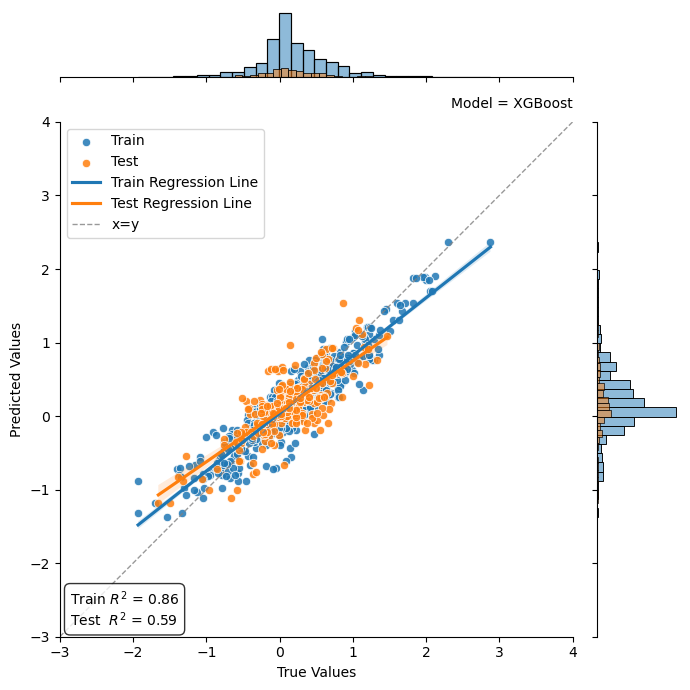

Saved figure -> outputs/pred_vs_true_joint.png


<Figure size 640x480 with 0 Axes>

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

# 组装数据
df_train_plot = pd.DataFrame({"True": y_train, "Predicted": pred_train, "Split": "Train"})
df_test_plot  = pd.DataFrame({"True": y_test,  "Predicted": pred_test,  "Split": "Test"})
df_all = pd.concat([df_train_plot, df_test_plot], ignore_index=True)

# 轴范围（可按需要调整）
x_min = np.floor(df_all["True"].min()  - 0.2)
x_max = np.ceil( df_all["True"].max()  + 0.2)
y_min = np.floor(df_all["Predicted"].min() - 0.2)
y_max = np.ceil( df_all["Predicted"].max() + 0.2)

# JointGrid
g = sns.JointGrid(data=df_all, x="True", y="Predicted", height=7, xlim=(x_min, x_max), ylim=(y_min, y_max))

# 中心散点（分训练/测试）
g.ax_joint.scatter(df_train_plot["True"], df_train_plot["Predicted"],
                   s=36, alpha=0.85, edgecolor="white", linewidth=0.6, label="Train")
g.ax_joint.scatter(df_test_plot["True"], df_test_plot["Predicted"],
                   s=36, alpha=0.85, edgecolor="white", linewidth=0.6, label="Test")

# 两条回归线
sns.regplot(data=df_train_plot, x="True", y="Predicted", scatter=False, ax=g.ax_joint, label="Train Regression Line")
sns.regplot(data=df_test_plot,  x="True", y="Predicted", scatter=False, ax=g.ax_joint, label="Test Regression Line")

# x=y 参考线
lims = [min(x_min, y_min), max(x_max, y_max)]
g.ax_joint.plot(lims, lims, ls="--", linewidth=1, color="gray", alpha=0.8, label="x=y")
g.ax_joint.set_xlim(lims)
g.ax_joint.set_ylim(lims)


# 顶部：True 的直方图
sns.histplot(pd.to_numeric(df_train_plot["True"], errors="coerce").dropna(),
             bins=30, ax=g.ax_marg_x, alpha=0.5)
sns.histplot(pd.to_numeric(df_test_plot["True"], errors="coerce").dropna(),
             bins=30, ax=g.ax_marg_x, alpha=0.5)

# 右侧：Predicted 的直方图（放在 y 轴上）
sns.histplot(y=pd.to_numeric(df_train_plot["Predicted"], errors="coerce").dropna(),
             bins=30, ax=g.ax_marg_y, alpha=0.5)
sns.histplot(y=pd.to_numeric(df_test_plot["Predicted"], errors="coerce").dropna(),
             bins=30, ax=g.ax_marg_y, alpha=0.5)


# 文字与样式
g.ax_joint.set_xlabel("True Values")
g.ax_joint.set_ylabel("Predicted Values")
g.ax_joint.set_title("Model = XGBoost", loc="right", fontsize=10, pad=10)

# R^2 文本框
box_text = f"Train $R^2$ = {r2_train:.2f}\nTest  $R^2$ = {r2_test:.2f}"
bbox = dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.8)
g.ax_joint.text(0.02, 0.02, box_text, transform=g.ax_joint.transAxes, fontsize=10, bbox=bbox)

# 图例
g.ax_joint.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

# 同时保存文件
import pathlib
pathlib.Path("outputs").mkdir(exist_ok=True)
plt.savefig("outputs/pred_vs_true_joint.png", dpi=300, bbox_inches="tight")
print("Saved figure -> outputs/pred_vs_true_joint.png")


## 7. 交叉验证（可选）


In [8]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(pipe, X_df, y, cv=5, scoring='r2', n_jobs=-1).mean()
print(f"5-Fold CV R2: {cv_score:.4f}")


5-Fold CV R2: -0.0881


## 8. 编码后特征名（`get_feature_names_out`）


In [9]:
# 拿到 OHE 后的特征名：数值列 + 类别展开列
pre = pipe.named_steps['pre']
ohe = pre.named_transformers_['cat']

# 数值列本身名
num_names = num_cols.copy()

# 类别列展开的列名
cat_names = list(ohe.get_feature_names_out(cat_cols))

feature_names = num_names + cat_names
print("Encoded feature count:", len(feature_names))
feature_names[:20]


Encoded feature count: 200


['Molecular weight',
 'Atomic number of metal',
 'Number of metals',
 'Number of oxygen atom',
 'Metal electronegativity',
 'Period number of metal',
 'Nanoparticle size',
 'Exposure time/d',
 'Exposure duration/d',
 'DOI_ 10.1007/s11356-017-8880-1',
 'DOI_10.1007/s00344-023-11204-8',
 'DOI_10.1007/s11051-012-1125-9',
 'DOI_10.1007/s11099-015-0167-5  ',
 'DOI_10.1007/s11270-011-1067-3',
 'DOI_10.1007/s11270-020-04592-0',
 'DOI_10.1007/s11356-023-30411-0',
 'DOI_10.1007/s11356-024-34412-5',
 'DOI_10.1007/s11738-014-1667-9',
 'DOI_10.1007/s13205-018-1386-9',
 'DOI_10.1016/j.chemosphere.2013.05.044']

## 9. 导出预测与特征重要性


In [10]:
from pathlib import Path
import pandas as pd

out_dir = Path("./outputs")
out_dir.mkdir(exist_ok=True)

# 保存测试集预测
pred_df = pd.DataFrame({
    "True": y_test,
    "Predicted": pred_test
})
pred_path = out_dir / "predictions_xgb.xlsx"
pred_df.to_excel(pred_path, index=False)
print("Saved predictions ->", pred_path.resolve())

# 基于 booster 的特征重要性（注意：这与编码后的列名一一对应需要提取 pipeline 中的矩阵）
# 简化：这里用 X_train 经过预处理后的矩阵 + 模型 feature_importances_
from sklearn import set_config
set_config(transform_output="pandas")
X_train_enc = pre.fit_transform(X_train)  # 注意：为了拿到列名，这里重新 fit 一次 preprocess（与上面 pipe.fit 参数一致）
X_train_enc.columns = feature_names

booster_importance = pipe.named_steps['xgb'].feature_importances_
fi_df = pd.DataFrame({"feature": X_train_enc.columns, "importance": booster_importance}).sort_values("importance", ascending=False)
fi_path = out_dir / "feature_importance_xgb.xlsx"
fi_df.to_excel(fi_path, index=False)
print("Saved feature importance ->", fi_path.resolve())

fi_df.head(20)


Saved predictions -> C:\Users\Lenovo\Downloads\outputs\predictions_xgb.xlsx
Saved feature importance -> C:\Users\Lenovo\Downloads\outputs\feature_importance_xgb.xlsx


,feature,importance
60,Plant species_Soybean,0.080485
120,Experimental environment_Not mentioned,0.035276
114,Medium description_soil with MNs,0.023743
65,Plant species_eggplant (Solanum melongena),0.021585
49,DOI_10.15666/aeer/1503_14991510,0.021241
83,Exposure target_nan,0.019839
161,Endpoints detail_GPOX in root,0.018602
149,Endpoints detail_ASA,0.018173
43,DOI_10.1021/es401032m,0.017777
154,Endpoints detail_CAT in shoot,0.015516


## 10. SHAP 模型解释（可选）


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21028\2798329837.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample_enc, feature_names=feature_names, show=False)


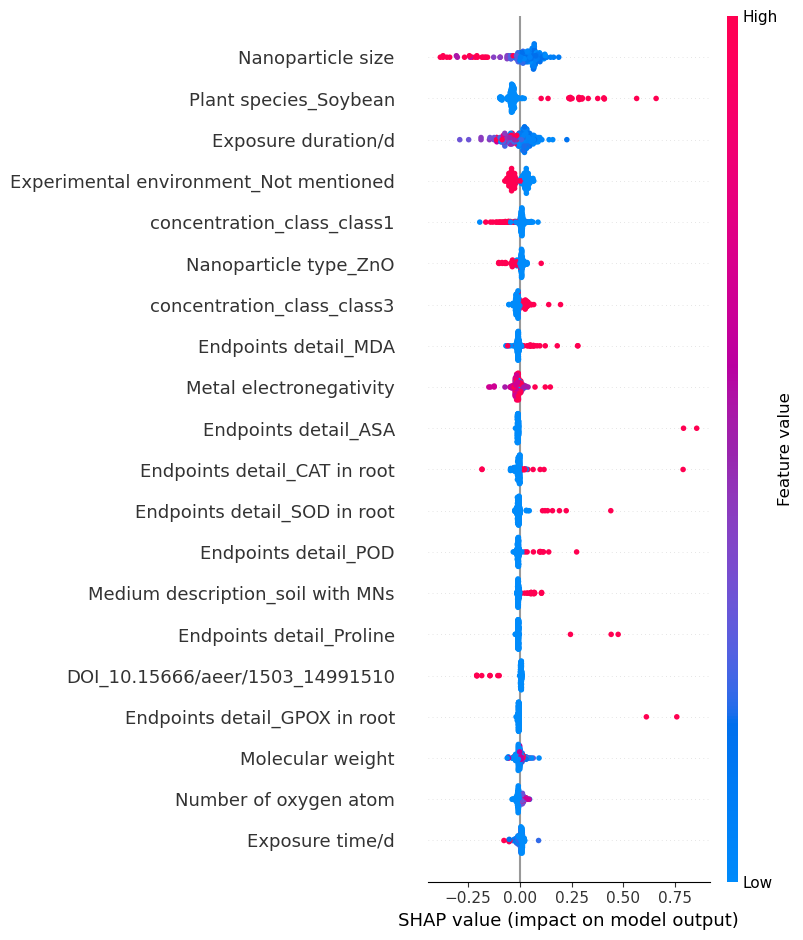

In [11]:
# 如果未安装：!pip install shap
try:
    import shap
    shap.initjs()
    # 使用一小部分样本做解释以节约时间
    X_sample = X_train.sample(n=min(200, len(X_train)), random_state=SEED)
    # 经过预处理
    X_sample_enc = pre.transform(X_sample)
    explainer = shap.TreeExplainer(pipe.named_steps['xgb'])
    shap_values = explainer.shap_values(X_sample_enc)
    # 总体特征重要性图（需要在 notebook 里显示）
    shap.summary_plot(shap_values, X_sample_enc, feature_names=feature_names, show=False)
except Exception as e:
    print("SHAP 可选步骤失败/未安装：", e)
